In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression  # Import LinearRegression
import statsmodels.api as sm  # Import statsmodels
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Datasets
df1 = pd.read_csv("df1.csv")
df2 = pd.read_csv("df2.csv")
df3 = pd.read_csv("df3.csv")
df4 = pd.read_csv("df4.csv")
teacher_df = pd.read_csv("dataprofessors.csv")

In [2]:
# Combining base data
df = pd.concat([df1, df2, df3, df4], ignore_index=True)
df.drop(columns=["magnitude", "qualifier"], inplace=True, errors='ignore')
df.rename(columns={
    'indicatorId': 'Indicator ID',
    'geoUnit': 'Geo-location',
    'year': 'Year',
    'value': 'Value'
}, inplace=True)
df["Year"] = df["Year"].astype(int)

# --- Data Validation and Cleaning ---
# 1. Check for and handle duplicates:
df.drop_duplicates(inplace=True)

# 2. Validate "Year" values (e.g., ensure they are within a specific range)
df = df[(df['Year'] >= 1990) & (df['Year'] <= 2023)] # Example range

# 3. Handle missing values (e.g., using imputation)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean') # Or other strategies
df['Value'] = imputer.fit_transform(df[['Value']])

In [3]:
df.head()

,Indicator ID,Geo-location,Year,Value
0,CR.1,AFG,2011,40.725689
1,CR.1,AFG,2015,54.484638
2,CR.1,AFG,2022,44.242260
3,CR.1,AGO,2015,59.955662
4,CR.1,ALB,2017,97.430573


In [4]:
# --- Pivoting and Merging (similar to original code) ---

# Pivoting
df_pivoted = df.pivot(index=["Geo-location", "Year"], columns="Indicator ID", values="Value").reset_index()

# Teachers indicators
selected_ids = ['PTRHC.1.TRAINED', 'PTRHC.1.QUALIFIED', 'TATTRR.1']
teacher_filtered = teacher_df[teacher_df['indicatorId'].isin(selected_ids)]
teacher_pivot = teacher_filtered.pivot_table(
    index=['geoUnit', 'year'],
    columns='indicatorId',
    values='value'
).reset_index()
teacher_pivot.rename(columns={
    'geoUnit': 'Geo-location',
    'year': 'Year',
    'PTRHC.1.TRAINED': 'Trained_Teachers_Primary',
    'PTRHC.1.QUALIFIED': 'Qualified_Teachers_Primary',
    'TATTRR.1': 'Attrition_Teachers_Primary'
}, inplace=True)

# Merging all indicators
df_combined = pd.merge(df_pivoted, teacher_pivot, on=["Geo-location", "Year"], how="left")

In [5]:
df_combined.head()

,Geo-location,Year,CR.1,CR.2,CR.3,MATH.LOWERSEC,MATH.PRIMARY,READ.LOWERSEC,READ.PRIMARY,ROFST.1T3.CP,...,SCHBSP.2.WCOMPUT,SCHBSP.2.WELEC,SCHBSP.2.WINTERN,XGDP.FSGOV,XGOVEXP.IMF,YADULT.PROFILITERACY,YADULT.PROFINUMERACY,Qualified_Teachers_Primary,Trained_Teachers_Primary,Attrition_Teachers_Primary
0,ABW,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,100.0,100.0,NaN,6.751090,22.176781,NaN,NaN,NaN,16.822531,NaN
1,ABW,2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,5.914670,21.750540,NaN,NaN,NaN,15.111110,NaN
2,ABW,2012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,6.347290,20.634081,NaN,NaN,NaN,14.862880,NaN
3,ABW,2013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,6.442960,21.877630,NaN,NaN,NaN,NaN,NaN
4,ABW,2014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,4.857418,19.617979,NaN,NaN,NaN,NaN,NaN


Geo-location                     0
Year                             0
CR.1                          4126
CR.2                          4074
CR.3                          4068
MATH.LOWERSEC                 4700
MATH.PRIMARY                  4729
READ.LOWERSEC                 4741
READ.PRIMARY                  4798
ROFST.1T3.CP                  3428
SCHBSP.1.WCOMPUT              2758
SCHBSP.1.WELEC                1889
SCHBSP.1.WINTERN              3030
SCHBSP.2.WCOMPUT              2884
SCHBSP.2.WELEC                2041
SCHBSP.2.WINTERN              3021
XGDP.FSGOV                    2832
XGOVEXP.IMF                   2348
YADULT.PROFILITERACY          5065
YADULT.PROFINUMERACY          5067
Qualified_Teachers_Primary    2365
Trained_Teachers_Primary      2012
Attrition_Teachers_Primary    4125
dtype: int64


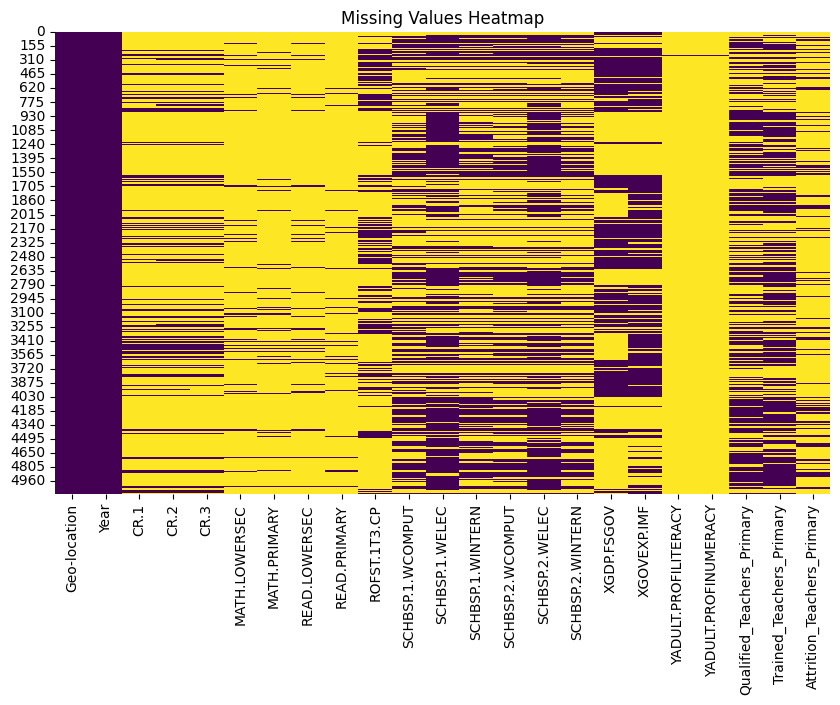

In [6]:
# Check for missing values in the combined dataframe
missing_values = df_combined.isnull().sum()
print(missing_values)

# Visualize missing values (optional)
plt.figure(figsize=(10, 6))
sns.heatmap(df_combined.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [7]:
# Final features and target
features = [
    'ROFST.1T3.CP',               # Out-of-school rate
    'XGDP.FSGOV',                 # Government education spending
    'Trained_Teachers_Primary',  # % of trained teachers
    'SCHBSP.1.WINTERN'            # Internet in schools
]
target = 'MATH.PRIMARY'

In [8]:
# Data Cleaning and Preprocessing
imputer = KNNImputer(n_neighbors=5)  # Using KNN imputation
df_combined[features + [target]] = imputer.fit_transform(df_combined[features + [target]])

In [9]:
df_reg = df_combined.dropna(subset=[target] + features).copy()

#Defining X and Y
X = df_reg[features]
y = df_reg[target].reset_index(drop=True)

In [10]:
#Standarizing values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)

X_scaled = sm.add_constant(X_scaled) #adding intercept

In [11]:
# --- Linear Rgression ---
model = LinearRegression()  # Create a LinearRegression object

# --- Performing Cross-Validation ---
cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='neg_mean_squared_error')
print("Cross-validation MSE scores:", -cv_scores)
print("Average MSE:", -cv_scores.mean())

Cross-validation MSE scores: [193.76465308  98.32074135 238.57597214 247.72451364 121.60990968]
Average MSE: 179.99915797476268


In [12]:
# Regression
model_std = sm.OLS(y, X_scaled).fit()
print(model_std.summary())

                            OLS Regression Results                            
Dep. Variable:           MATH.PRIMARY   R-squared:                       0.512
Model:                            OLS   Adj. R-squared:                  0.512
Method:                 Least Squares   F-statistic:                     1338.
Date:                Fri, 09 May 2025   Prob (F-statistic):               0.00
Time:                        12:56:06   Log-Likelihood:                -20446.
No. Observations:                5106   AIC:                         4.090e+04
Df Residuals:                    5101   BIC:                         4.094e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [13]:
# Feature Selection and Multicollinearity Check (VIF) = if more than 10 we have a multicollinearity issue
vif_data = pd.DataFrame()
vif_data['Feature'] = X_scaled.columns
vif_data['VIF'] = [variance_inflation_factor(X_scaled.values, i) for i in range(X_scaled.shape[1])]
vif_data = vif_data[vif_data['Feature'] != 'const']  # Filter out the constant term
print("\nVariance Inflation Factors (VIF):\n", vif_data)


Variance Inflation Factors (VIF):
                     Feature       VIF
1              ROFST.1T3.CP  1.938106
2                XGDP.FSGOV  1.155923
3  Trained_Teachers_Primary  1.597858
4          SCHBSP.1.WINTERN  1.756577


In [14]:
# --- Model Performance ---
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.fit(X_scaled, y).predict(X_scaled)
print("MAE:", mean_absolute_error(y, y_pred))
print("R² Score:", r2_score(y, y_pred))

MAE: 10.213346830444388
R² Score: 0.5120105400062089


<ipython-input-15-e8d0813fdf33>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df_std, x='Standardized Coefficient', y='Feature', palette='coolwarm')


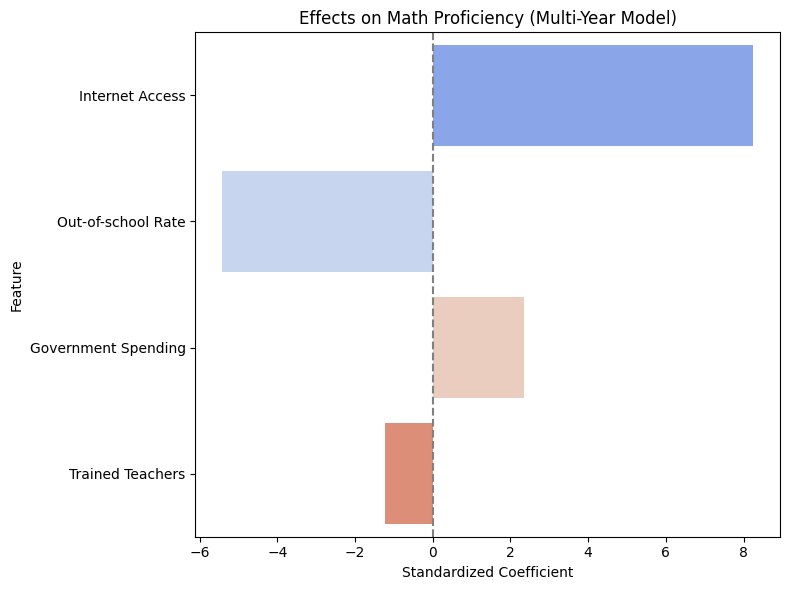

In [15]:
# Feature renaming
feature_names = {
    'ROFST.1T3.CP': 'Out-of-school Rate',
    'XGDP.FSGOV': 'Government Spending',
    'Trained_Teachers_Primary': 'Trained Teachers',
    'SCHBSP.1.WINTERN': 'Internet Access'
}

# Creating DataFrame for coefficients
coef_df_std = pd.DataFrame({
    'Feature': model_std.params.index,
    'Standardized Coefficient': model_std.params.values
}).query("Feature != 'const'") \
    .replace({'Feature': feature_names}) \
    .sort_values(by='Standardized Coefficient', key=abs, ascending=False)

#Plot
plt.figure(figsize=(8, 6))
sns.barplot(data=coef_df_std, x='Standardized Coefficient', y='Feature', palette='coolwarm')
plt.axvline(0, color='gray', linestyle='--')
plt.title('Effects on Math Proficiency (Multi-Year Model)')
plt.tight_layout()
plt.show()

In [17]:
# Train-Test Split
from sklearn.model_selection import train_test_split # Importing train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Model Building and Evaluation
X_train_const = sm.add_constant(X_train)  # Add constant for training
model = sm.OLS(y_train, X_train_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           MATH.PRIMARY   R-squared:                       0.515
Model:                            OLS   Adj. R-squared:                  0.515
Method:                 Least Squares   F-statistic:                     1083.
Date:                Fri, 09 May 2025   Prob (F-statistic):               0.00
Time:                        12:56:28   Log-Likelihood:                -16336.
No. Observations:                4084   AIC:                         3.268e+04
Df Residuals:                    4079   BIC:                         3.271e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   